# Analysis of the RV datasets from the CLS survey by Rosenthal et al. (2021)

This notebook will use the California Legacy Survey Data to test the use of the fdac module 

#### Imports

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#make better plots
import scienceplots
plt.style.use(['science','notebook','grid'])
plt.rcParams.update({"font.size" : 26})
plt.rcParams.update({"axes.labelsize" : 26})
plt.rcParams.update({"xtick.labelsize" : 22})
plt.rcParams.update({"ytick.labelsize" : 22})
plt.rcParams.update({"axes.titlesize" : 26})
plt.rcParams.update({"figure.figsize": (9,6)})
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

## 1. HD 99491

Text(0.5, 0, 'JD')

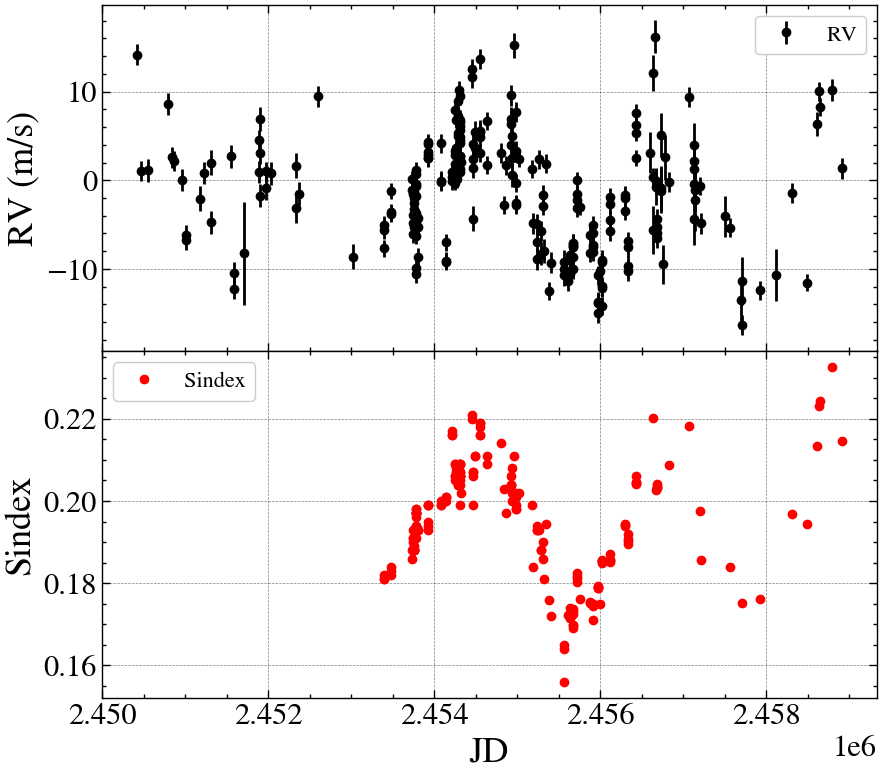

In [2]:
data_cls = pd.read_csv('../../data/legacy_data.csv')
hd99491 = data_cls[data_cls['name']=='99491'].reset_index(drop=True)

labels = ['RV', "Sindex"]
#plot the velocities, S index and H alpha
fig , ax = plt.subplots(figsize = (10,9), nrows = 2, sharex = True, \
                               gridspec_kw = {'wspace':0, 'hspace':0})

ax[0].errorbar(hd99491['jd'], hd99491['mnvel'],yerr = hd99491['errvel'], \
                       fmt = 'o',color ='k', label = labels[0])
ax[0].set_ylabel('RV (m/s)')
ax[0].legend()
ax[1].errorbar(hd99491['jd'], hd99491['sval'], color ='r',fmt = 'o', label =labels[1])
ax[1].set_ylabel(labels[1])
ax[1].legend()
ax[1].set_xlabel('JD')

## 2. Create the fdac object

In [3]:
import sys
import os

# Get the path to the src folder relative to the notebook
src_path = os.path.abspath(os.path.join(os.pardir,os.pardir, "src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

#Import the module
from fdac import fdac

In [4]:
hd99491.columns

Index(['Unnamed: 0', 'obs', 'name', 'jd', 'mnvel', 'errvel', 'sval', 'cts',
       'tel'],
      dtype='object')

In [5]:
timeseries = np.array(hd99491['sval']).reshape(1,-1)
rvs = np.array(hd99491['mnvel'])
time =np.array(hd99491['jd'])
fdac_91 = fdac.fdac(time,rvs, timeseries, ['RV', 'S-index'])

Mean Nyquist frequency:  0.014195310726544135 

Median Nyquist frequency:  0.2572638446166587 

10% trimmed Mean Nyquist frequency:  0.020377673202921387 

20% trimmed mean Nyqusit frequenct:  0.02832117939361329


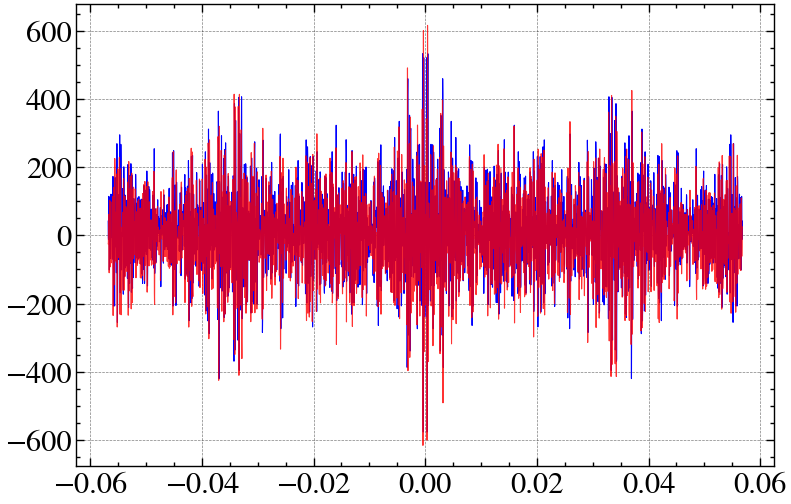

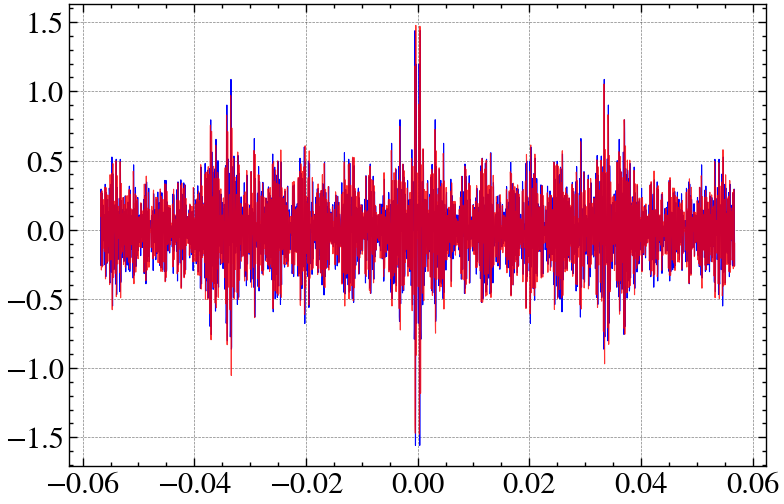

In [14]:
fdac_91.frequency_grid(4*fdac_91.Nyq_meandt, oversample=4)
fdac_91.computeNFFT()
plt.plot(fdac_91.fgrid, fdac_91.fft_list[0].real, label="Re", lw=0.8, color = 'b')
plt.plot(fdac_91.fgrid, fdac_91.fft_list[0].imag, label="Im", lw=0.8, alpha=0.8, color = 'r')
plt.figure()
plt.plot(fdac_91.fgrid, fdac_91.fft_list[1].real, label="Re", lw=0.8, color = 'b')
plt.plot(fdac_91.fgrid, fdac_91.fft_list[1].imag, label="Im", lw=0.8, alpha=0.8, color = 'r')

## 3. Fit the Multiple Linear Regression to the observations

In [15]:
fdac_91.linear_reg()

Coefficients
----
Coefficients: 
 [[385.07752392  16.08699539]
 [-16.39555837 385.08845686]]

Intercept
---------
Intercept: 
 0.0


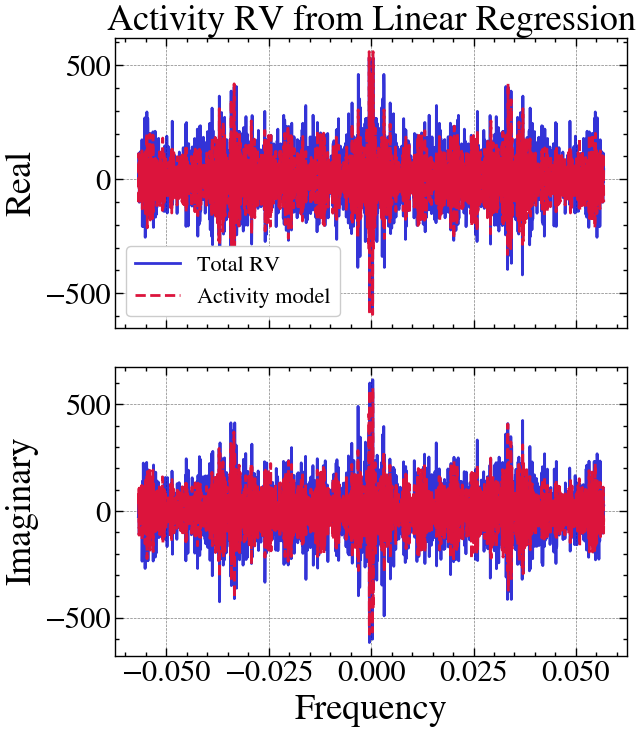

In [16]:
fdac_91.fftac_plot()

## 4. Get the time domain activity model and subtract to the residuals

46.02701905447867 6.711925062940002e-07
Raw standard deviation 6.4255
Variance ratio: 0.6365
Should be 1: 1.0000000000000002
Should be equal: 5.1262 5.1262
Inversion fully computed
Std dev of clean RV: 15.004171348360162


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


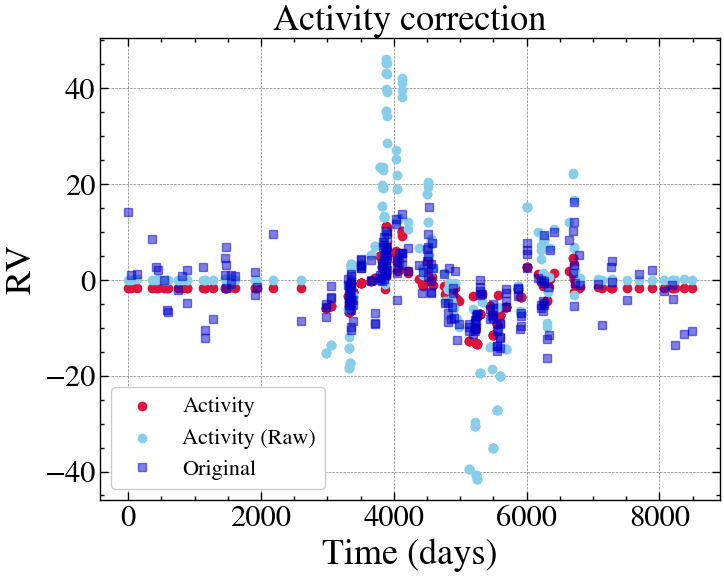

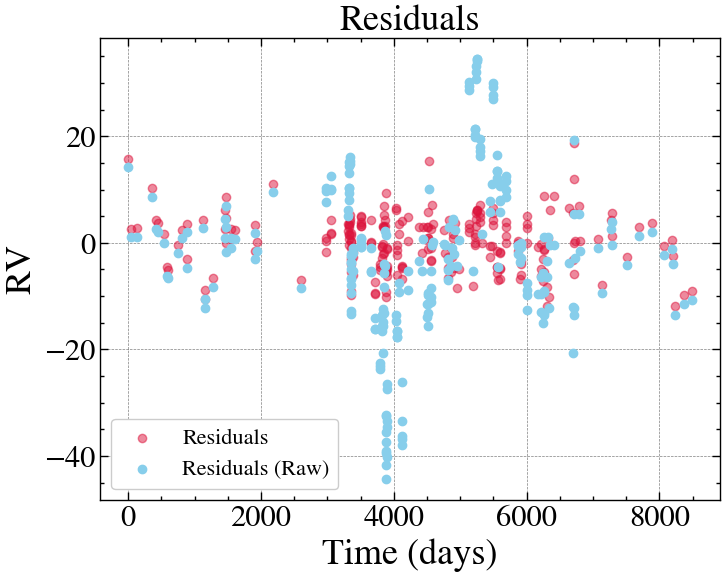

In [17]:
fdac_91.inverfft()
fdac_91.activityplot(clean = True)

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


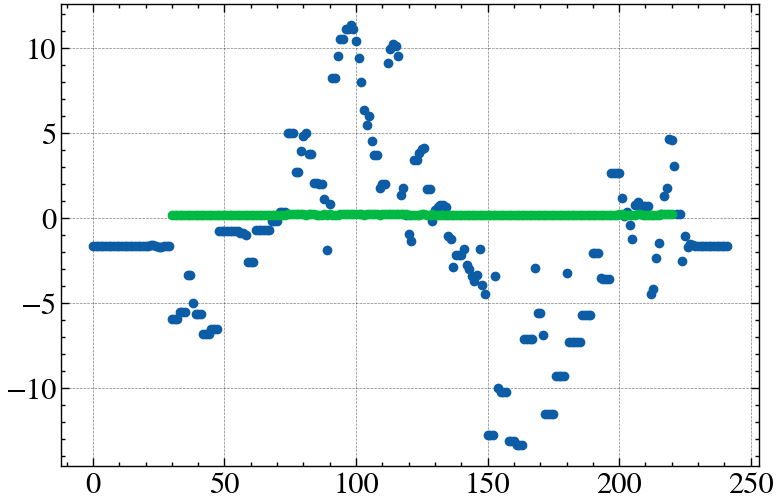

In [21]:
plt.plot(fdac_91.activity, 'o')
plt.plot(timeseries[0], 'o')

## 5. Analyze the performance of the acitivy model in subtracting the stellar signals in the data

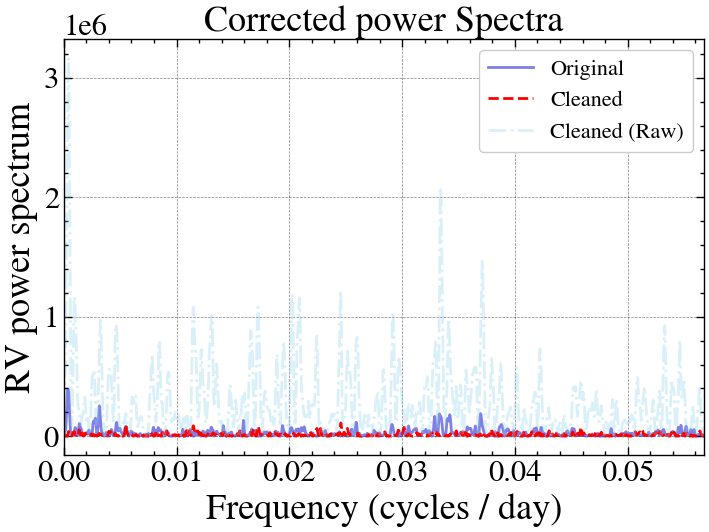

In [27]:
fdac_91.residual_powplot()
#plt.ylim(1e-2, 1e7)
#plt.xlim(-0.001,0.1)
plt.axvline(1/17.05, color='k', ls='--')

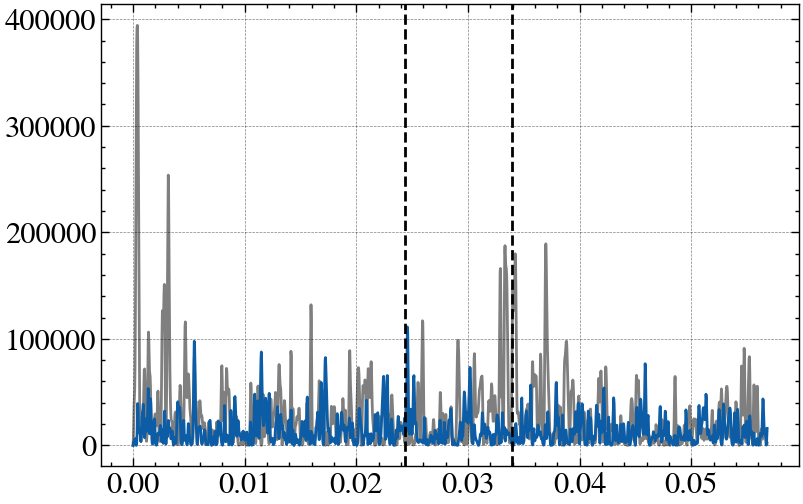

In [40]:
indeces = fdac_91.fgrid>=0
plt.plot(fdac_91.fgrid[indeces], np.abs(fdac_91.first_FFT[indeces])**2, color='k', alpha=0.5)
plt.plot(fdac_91.fgrid[indeces], np.abs(fdac_91.residuals_FFT[indeces])**2,alpha=1)
plt.axvline(1/41, color='k', ls='--')
plt.axvline(1/29.5, color='k', ls='--')

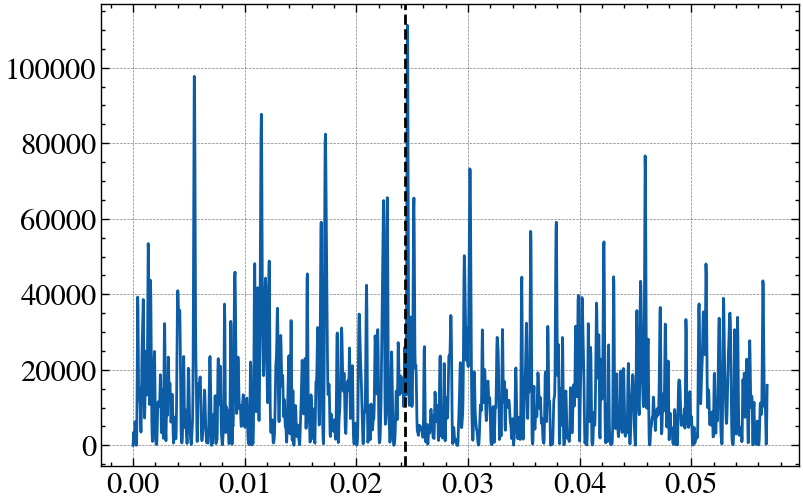

In [42]:
plt.plot(fdac_91.fgrid[indeces], np.abs(fdac_91.residuals_FFT[indeces])**2,alpha=1)
plt.axvline(1/41, color='k', ls='--')

## 2. HD 7924

Text(0.5, 0, 'JD')

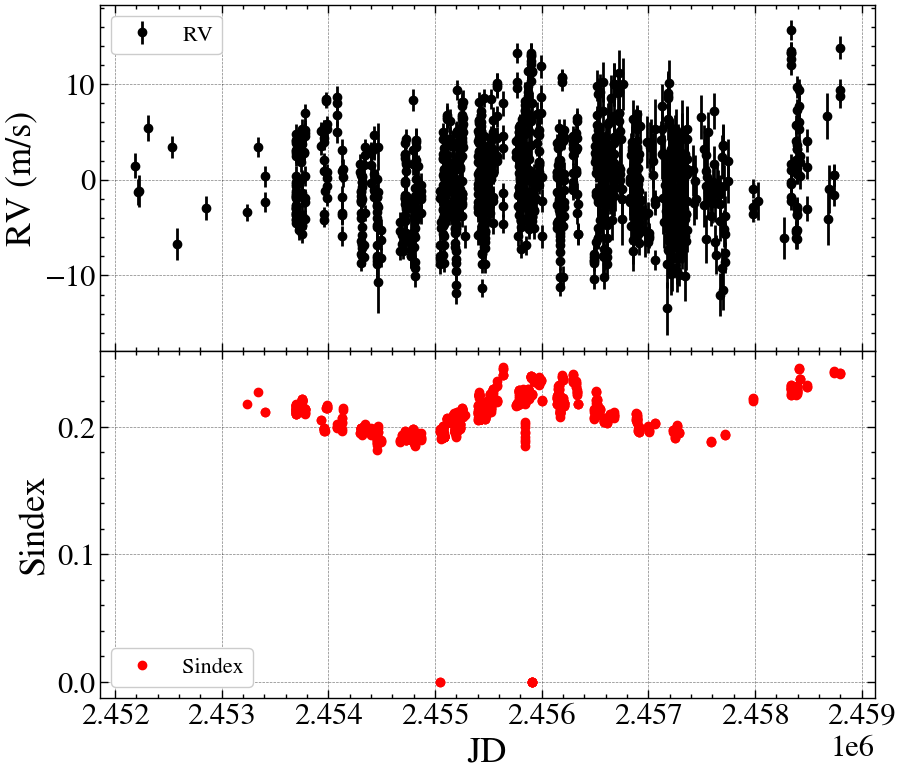

In [33]:
data_cls = pd.read_csv('../../data/legacy_data.csv')
hd7924 = data_cls[data_cls['name']=='7924'].reset_index(drop=True)

labels = ['RV', "Sindex"]
#plot the velocities, S index and H alpha
fig , ax = plt.subplots(figsize = (10,9), nrows = 2, sharex = True, \
                               gridspec_kw = {'wspace':0, 'hspace':0})

ax[0].errorbar(hd7924['jd'], hd7924['mnvel'],yerr = hd7924['errvel'], \
                       fmt = 'o',color ='k', label = labels[0])
ax[0].set_ylabel('RV (m/s)')
ax[0].legend()
ax[1].errorbar(hd7924['jd'], hd7924['sval'], color ='r',fmt = 'o', label =labels[1])
ax[1].set_ylabel(labels[1])
ax[1].legend()
ax[1].set_xlabel('JD')

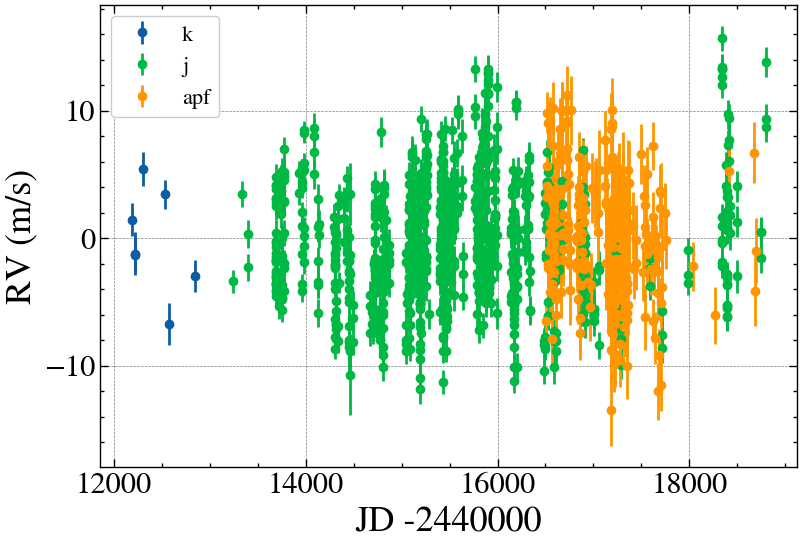

In [35]:
telescopes = hd7924.tel.unique()
for i in telescopes:
    plt.errorbar(hd7924.jd[hd7924['tel']==i] -2440000, hd7924.mnvel[hd7924['tel']==i], \
                 yerr=hd7924.errvel[hd7924['tel']==i], fmt = 'o', label = i)
plt.xlabel('JD -2440000')
plt.ylabel('RV (m/s)')
plt.legend()

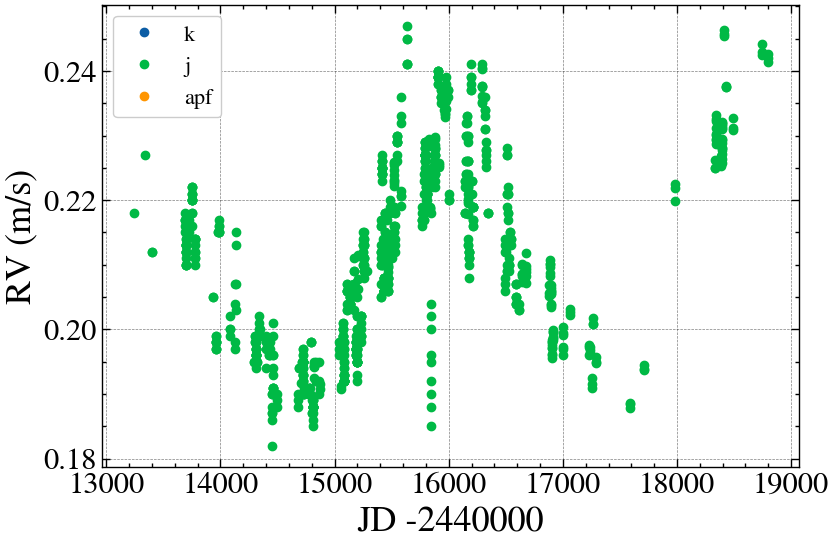

In [64]:
for i in telescopes:
    plt.errorbar(hd7924.jd[hd7924['tel']==i] -2440000, hd7924.sval[hd7924['tel']==i], fmt = 'o', label = i)
plt.xlabel('JD -2440000')
plt.ylabel('RV (m/s)')
plt.legend()

In [63]:
hd7924.sval[hd7924.sval==0] = np.nan

/var/folders/yk/b36tymm90p1cnv5qffdwp2z40000gn/T/ipykernel_59782/2723223293.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  hd7924.sval[hd7924.sval==0] = np.nan
/var/folders/yk/b36tymm90p1cnv5qffdwp2z40000gn/T/ipykernel_59782/2723223293.

In [65]:
timeseries = np.array(hd7924.sval[hd7924['tel']=='j']).reshape(1,-1)
rvs = np.array(hd7924.mnvel[hd7924['tel']=='j'])
time =np.array(hd7924['jd'][hd7924['tel']=='j'])
fdac_79 = fdac.fdac(time,rvs, timeseries, ['RV', 'S-index'])

Mean Nyquist frequency:  0.0863041158992987 

Median Nyquist frequency:  286.2049176176694 

10% trimmed Mean Nyquist frequency:  0.4112726155266326 

20% trimmed mean Nyqusit frequenct:  0.9836588427517053


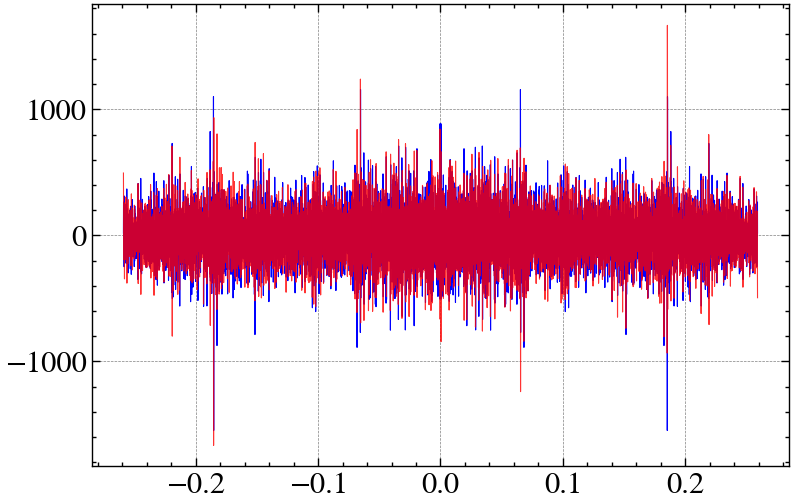

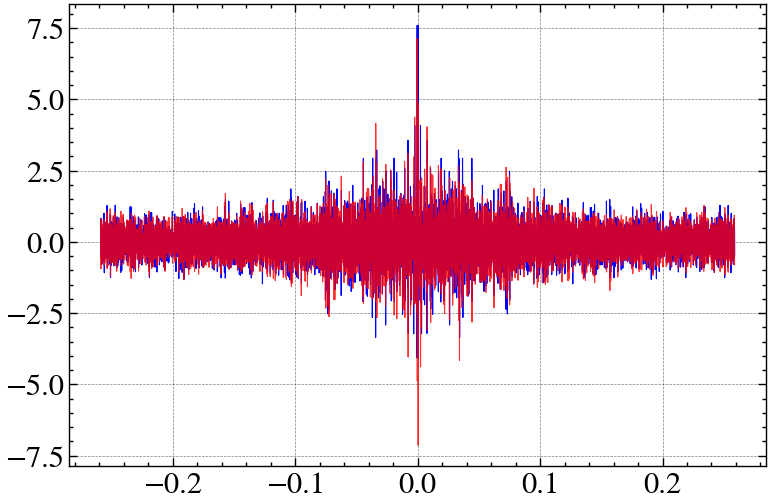

In [66]:
fdac_79.frequency_grid(3*fdac_79.Nyq_meandt, oversample=4)
fdac_79.computeNFFT()
plt.plot(fdac_79.fgrid, fdac_79.fft_list[0].real, label="Re", lw=0.8, color = 'b')
plt.plot(fdac_79.fgrid, fdac_79.fft_list[0].imag, label="Im", lw=0.8, alpha=0.8, color = 'r')
plt.figure()
plt.plot(fdac_79.fgrid, fdac_79.fft_list[1].real, label="Re", lw=0.8, color = 'b')
plt.plot(fdac_79.fgrid, fdac_79.fft_list[1].imag, label="Im", lw=0.8, alpha=0.8, color = 'r')

In [67]:
fdac_79.linear_reg()

Coefficients
----
Coefficients: 
 [[140.05790488  -1.59124342]
 [  1.59304774 140.21852652]]

Intercept
---------
Intercept: 
 0.0


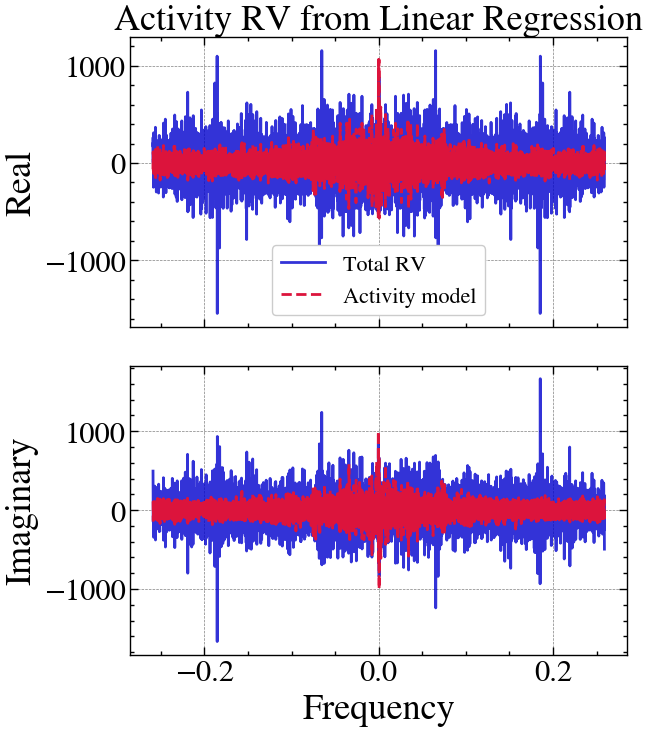

In [68]:
fdac_79.fftac_plot()

25.79805819645342 1.3547474196926865e-06
Raw standard deviation 4.6130
Variance ratio: 0.2089
Should be 1: 1.0
Should be equal: 2.1082 2.1082
Inversion fully computed
Std dev of clean RV: 8.9004395355836


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


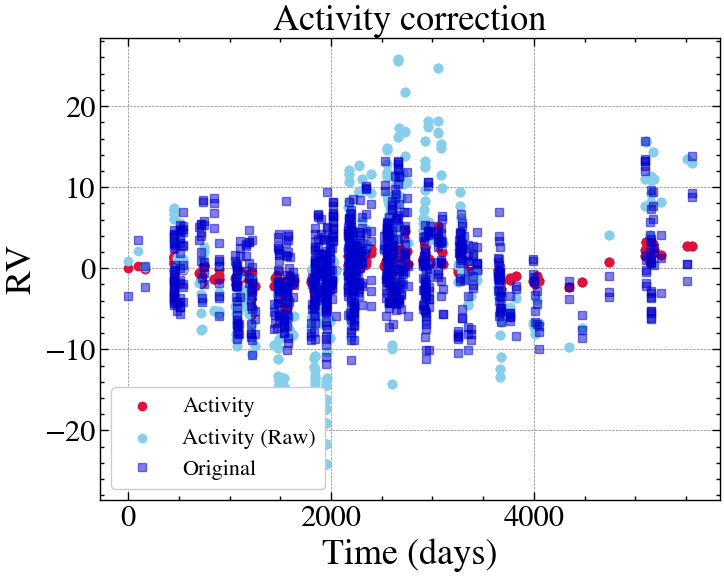

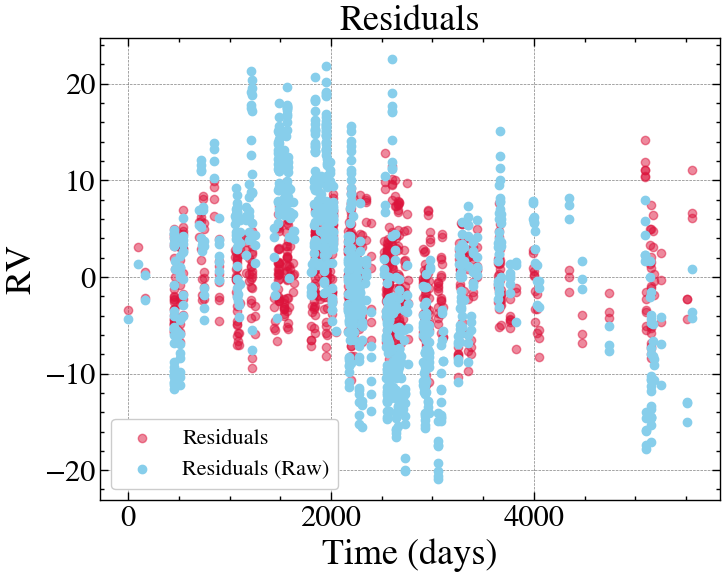

In [69]:
fdac_79.inverfft()
fdac_79.activityplot(clean = True)

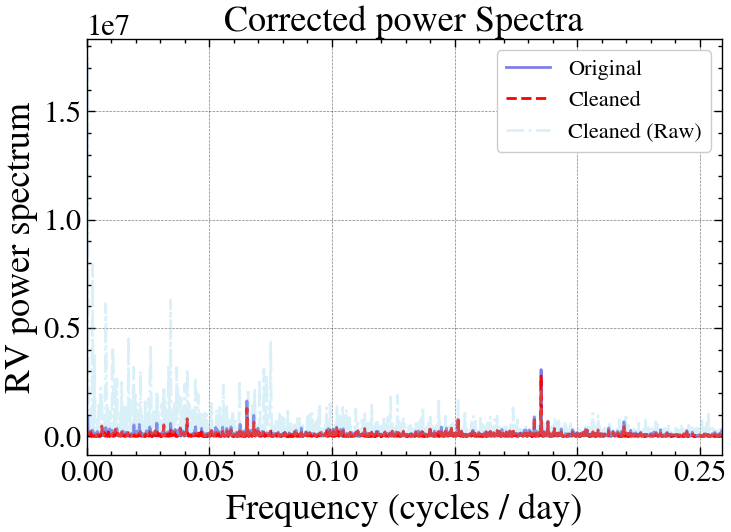

In [70]:
fdac_79.residual_powplot()
#plt.ylim(1e-2, 1e7)
#plt.xlim(-0.001,0.1)
#plt.axvline(1/17.05, color='k', ls='--')

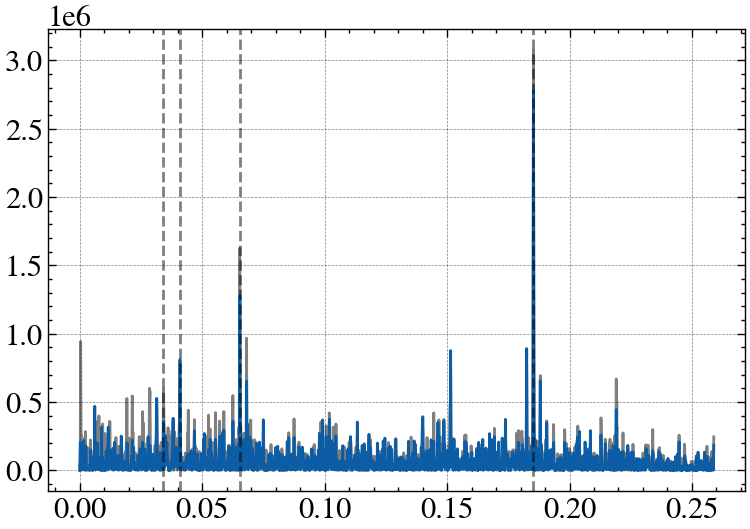

In [73]:
indeces = fdac_79.fgrid>=0
plt.plot(fdac_79.fgrid[indeces], np.abs(fdac_79.first_FFT[indeces])**2, color='k', alpha=0.5)
plt.plot(fdac_79.fgrid[indeces], np.abs(fdac_79.residuals_FFT[indeces])**2,alpha=1)
plt.axvline(1/5.397, color='k', ls='--', alpha=0.5)
plt.axvline(1/29.5, color='k', ls='--', alpha=0.5)
plt.axvline(1/15.3, color='k', ls='--', alpha =0.5)
plt.axvline(1/24.451, color='k', ls='--', alpha=0.5)

## 3. HD 219134

Text(0.5, 0, 'JD')

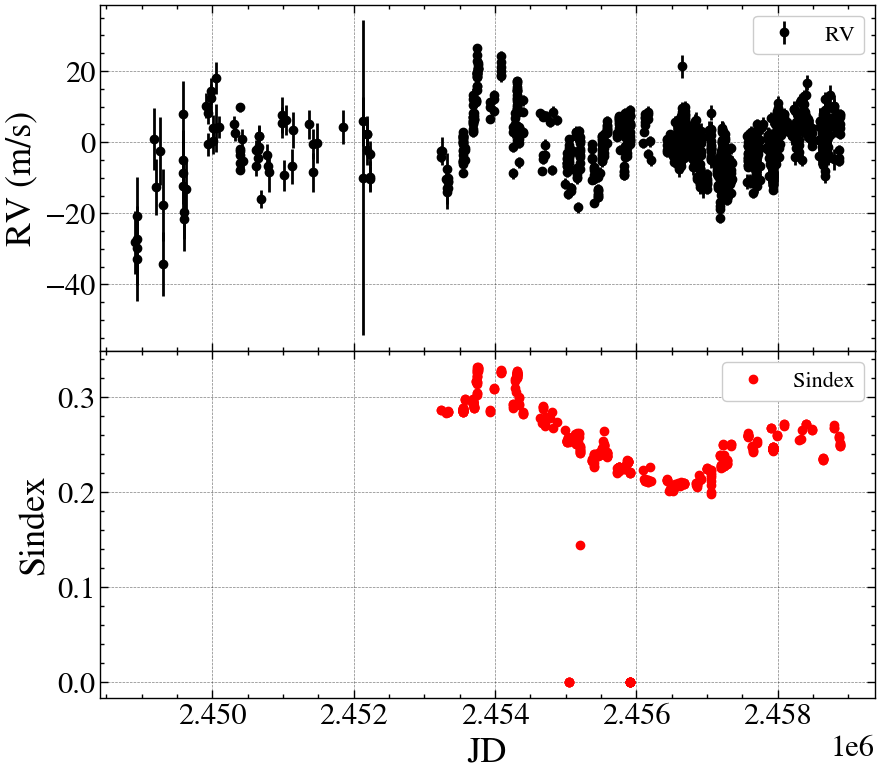

In [74]:
data_cls = pd.read_csv('../../data/legacy_data.csv')
hd219134 = data_cls[data_cls['name']=='219134'].reset_index(drop=True)

labels = ['RV', "Sindex"]
#plot the velocities, S index and H alpha
fig , ax = plt.subplots(figsize = (10,9), nrows = 2, sharex = True, \
                               gridspec_kw = {'wspace':0, 'hspace':0})

ax[0].errorbar(hd219134['jd'], hd219134['mnvel'],yerr = hd219134['errvel'], \
                       fmt = 'o',color ='k', label = labels[0])
ax[0].set_ylabel('RV (m/s)')
ax[0].legend()
ax[1].errorbar(hd219134['jd'], hd219134['sval'], color ='r',fmt = 'o', label =labels[1])
ax[1].set_ylabel(labels[1])
ax[1].legend()
ax[1].set_xlabel('JD')

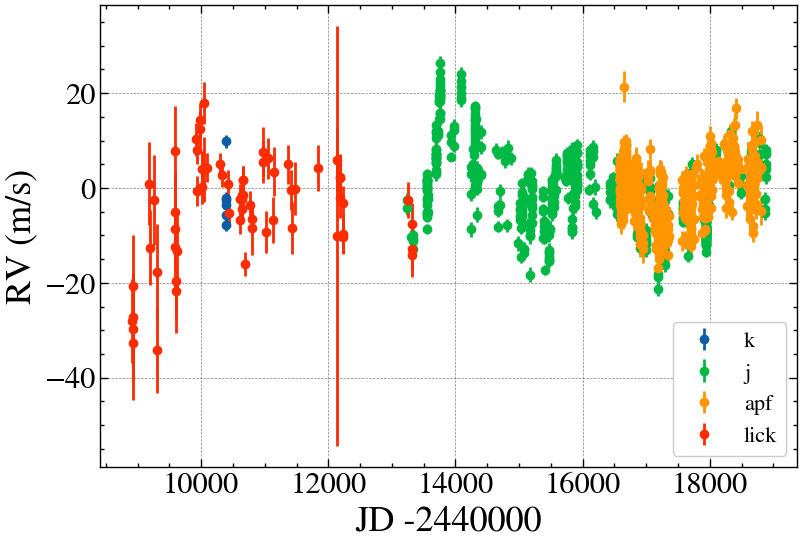

In [76]:
telescopes = hd219134.tel.unique()
for i in telescopes:
    plt.errorbar(hd219134.jd[hd219134['tel']==i] -2440000, hd219134.mnvel[hd219134['tel']==i], \
                 yerr=hd219134.errvel[hd219134['tel']==i], fmt = 'o', label = i)
plt.xlabel('JD -2440000')
plt.ylabel('RV (m/s)')
plt.legend()

In [78]:
hd219134.loc[hd219134.sval==0, "sval"] = np.nan

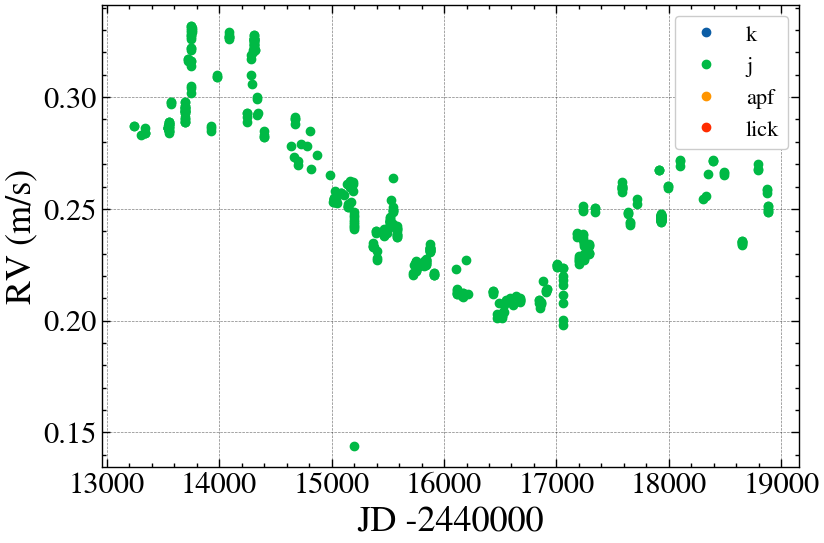

In [79]:
telescopes = hd219134.tel.unique()
for i in telescopes:
    plt.errorbar(hd219134.jd[hd219134['tel']==i] -2440000, hd219134.sval[hd219134['tel']==i], fmt = 'o', label = i)
plt.xlabel('JD -2440000')
plt.ylabel('RV (m/s)')
plt.legend()

In [82]:
timeseries = np.array(hd219134.sval[hd219134['tel']=='j']).reshape(1,-1)
rvs = np.array(hd219134.mnvel[hd219134['tel']=='j'])
time =np.array(hd219134['jd'][hd219134['tel']=='j'])
fdac_21 = fdac.fdac(time,rvs, timeseries, ['RV', 'S-index'])

Mean Nyquist frequency:  0.046005226402914386 

Median Nyquist frequency:  547.0459669859384 

10% trimmed Mean Nyquist frequency:  0.11587590607771578 

20% trimmed mean Nyqusit frequenct:  0.21941563861126756


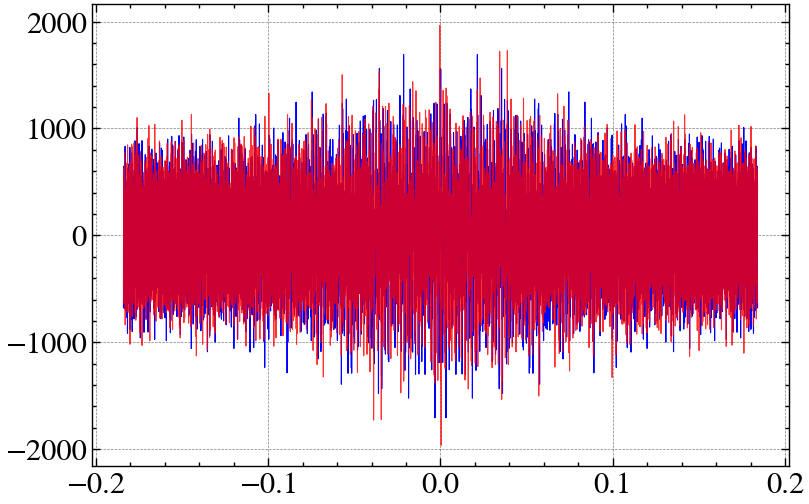

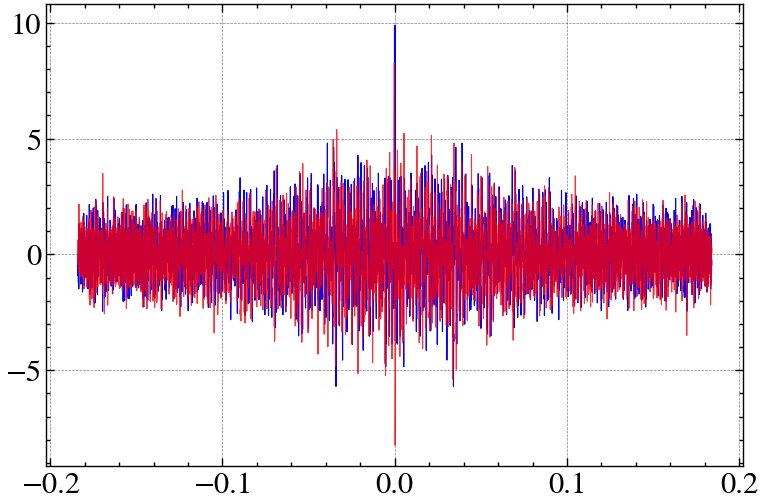

In [104]:
fdac_21.frequency_grid(4*fdac_21.Nyq_meandt, oversample=4)
fdac_21.computeNFFT()
plt.plot(fdac_21.fgrid, fdac_21.fft_list[0].real, label="Re", lw=0.8, color = 'b')
plt.plot(fdac_21.fgrid, fdac_21.fft_list[0].imag, label="Im", lw=0.8, alpha=0.8, color = 'r')
plt.figure()
plt.plot(fdac_21.fgrid, fdac_21.fft_list[1].real, label="Re", lw=0.8, color = 'b')
plt.plot(fdac_21.fgrid, fdac_21.fft_list[1].imag, label="Im", lw=0.8, alpha=0.8, color = 'r')

In [105]:
fdac_21.linear_reg()

Coefficients
----
Coefficients: 
 [[2.39213931e+02 2.19734123e-01]
 [7.93501170e-01 2.39945462e+02]]

Intercept
---------
Intercept: 
 0.0


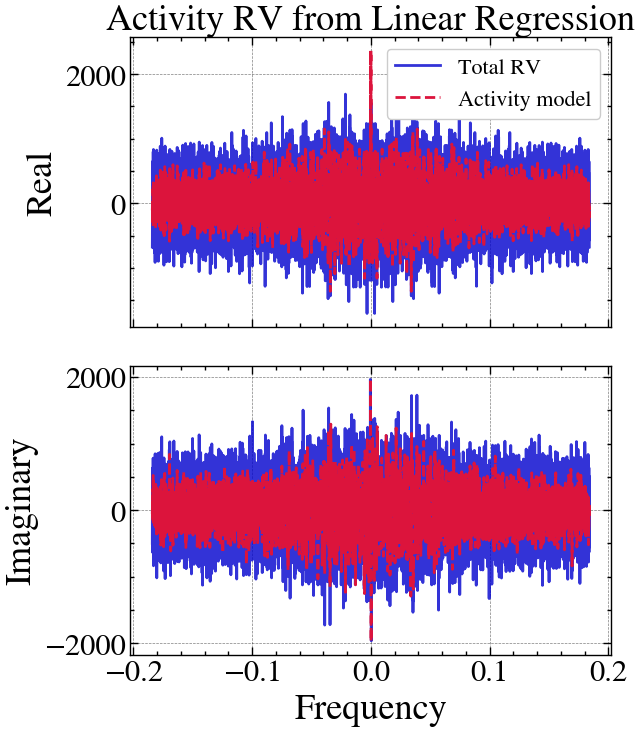

In [106]:
fdac_21.fftac_plot()

160.81286235750687 3.018193069913037e-06
Raw standard deviation 8.5793
Variance ratio: 0.3868
Should be 1: 1.0000000000000002
Should be equal: 5.3358 5.3358
Inversion fully computed
Std dev of clean RV: 65.85925095350497


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


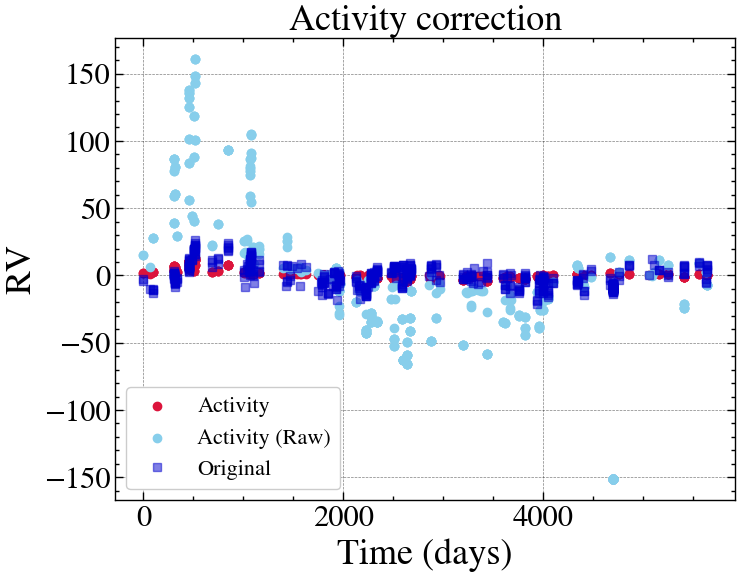

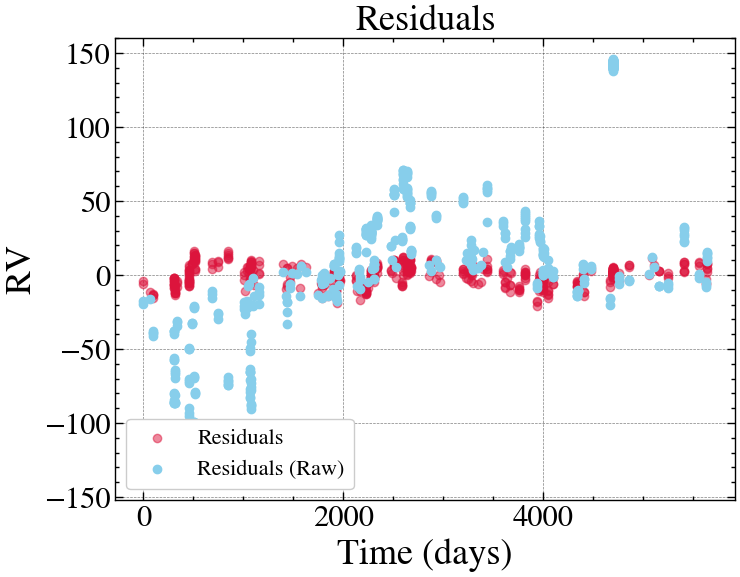

In [107]:
fdac_21.inverfft()
fdac_21.activityplot(clean = True)

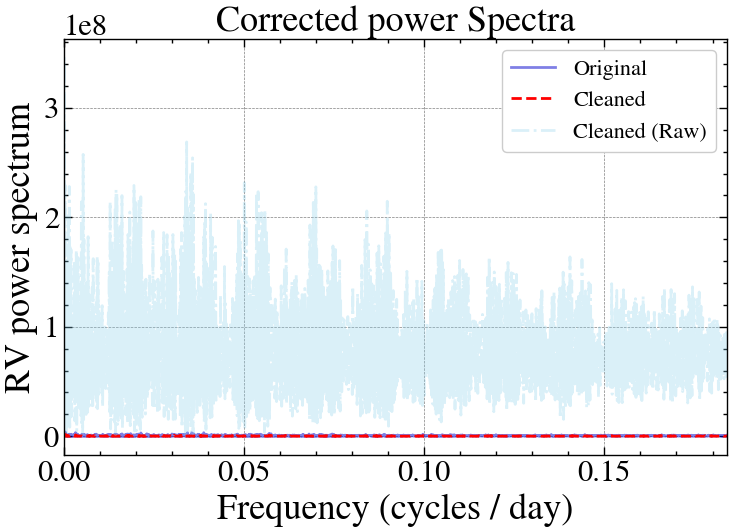

In [112]:
fdac_21.residual_powplot()
#plt.ylim(1e-2, 1e7)
#plt.xlim(-0.001,0.1)
#plt.axvline(1/17.05, color='k', ls='--')

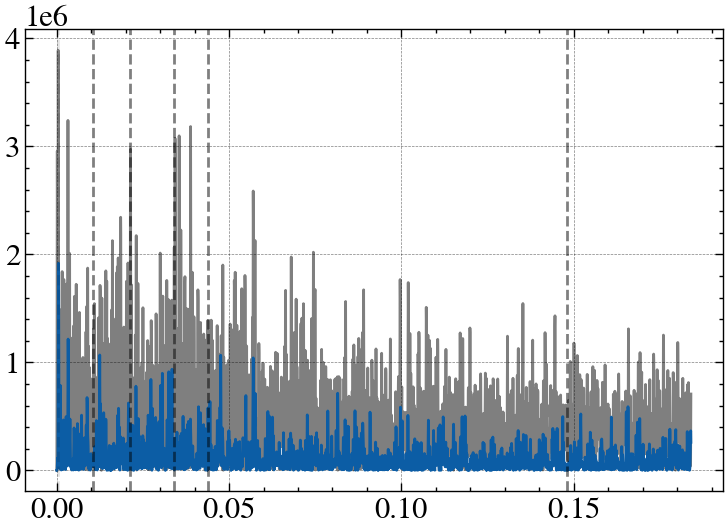

In [115]:
indeces = fdac_21.fgrid>=0
plt.plot(fdac_21.fgrid[indeces], np.abs(fdac_21.first_FFT[indeces])**2, color='k', alpha=0.5)
plt.plot(fdac_21.fgrid[indeces], np.abs(fdac_21.residuals_FFT[indeces])**2,alpha=1)
#plt.axvline(1/3.09, color='k', ls='--', alpha=0.5)
plt.axvline(1/29.5, color='k', ls='--', alpha=0.5)
plt.axvline(1/6.76, color='k', ls='--', alpha =0.5)
plt.axvline(1/22.79, color='k', ls='--', alpha=0.5)
plt.axvline(1/46.859, color='k', ls='--', alpha=0.5)
plt.axvline(1/94.2, color='k', ls='--', alpha=0.5)
plt.axvline(1/2240, color='k', ls='--', alpha=0.1)

## 4. HD 26965

Text(0.5, 0, 'JD')

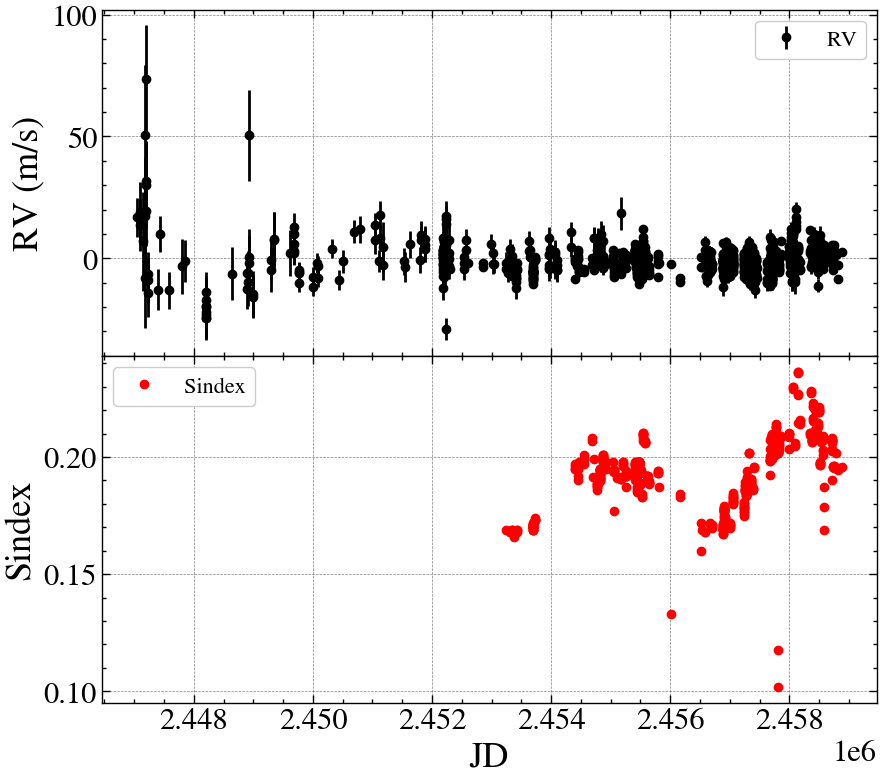

In [116]:
data_cls = pd.read_csv('../../data/legacy_data.csv')
hd26965 = data_cls[data_cls['name']=='26965'].reset_index(drop=True)

labels = ['RV', "Sindex"]
#plot the velocities, S index and H alpha
fig , ax = plt.subplots(figsize = (10,9), nrows = 2, sharex = True, \
                               gridspec_kw = {'wspace':0, 'hspace':0})

ax[0].errorbar(hd26965['jd'], hd26965['mnvel'],yerr = hd26965['errvel'], \
                       fmt = 'o',color ='k', label = labels[0])
ax[0].set_ylabel('RV (m/s)')
ax[0].legend()
ax[1].errorbar(hd26965['jd'], hd26965['sval'], color ='r',fmt = 'o', label =labels[1])
ax[1].set_ylabel(labels[1])
ax[1].legend()
ax[1].set_xlabel('JD')

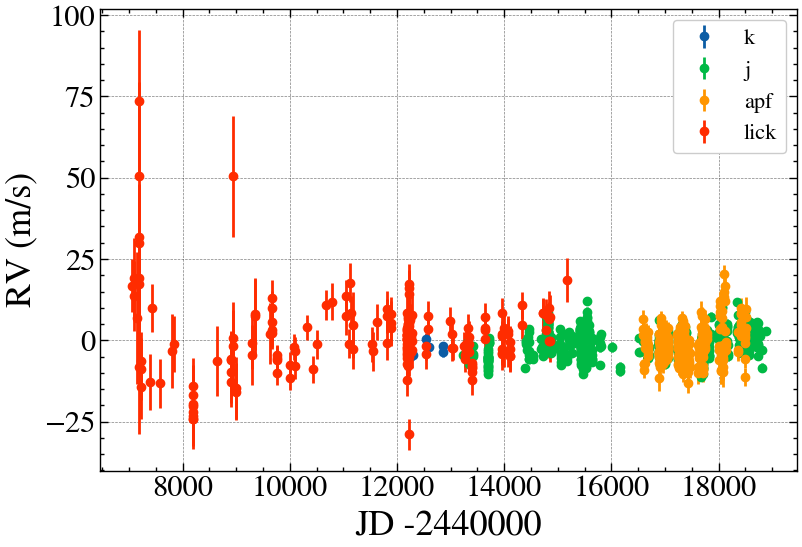

In [118]:
telescopes = hd26965.tel.unique()
for i in telescopes:
    plt.errorbar(hd26965.jd[hd26965['tel']==i] -2440000, hd26965.mnvel[hd26965['tel']==i], \
                 yerr=hd26965.errvel[hd26965['tel']==i], fmt = 'o', label = i)
plt.xlabel('JD -2440000')
plt.ylabel('RV (m/s)')
plt.legend()

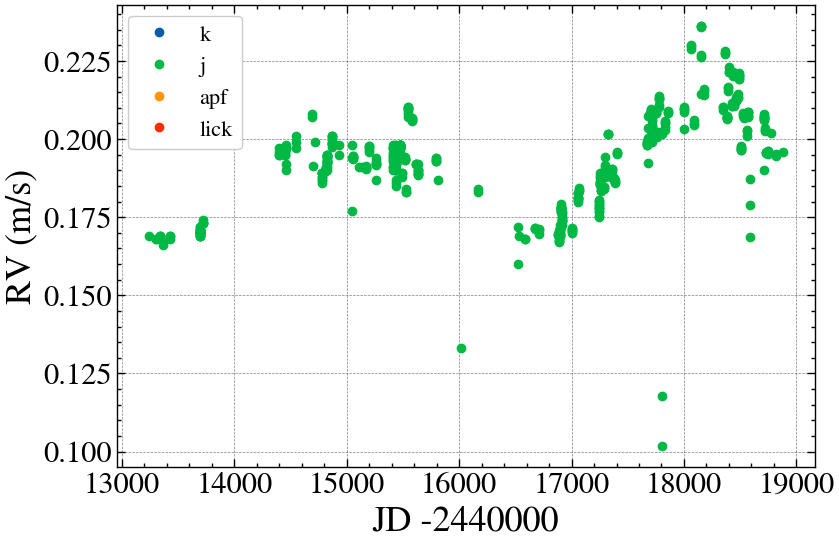

In [119]:
for i in telescopes:
    plt.errorbar(hd26965.jd[hd26965['tel']==i] -2440000, hd26965.sval[hd26965['tel']==i], fmt = 'o', label = i)
plt.xlabel('JD -2440000')
plt.ylabel('RV (m/s)')
plt.legend()

In [120]:
hd26965.loc[hd26965.sval<0.150, "sval"] = np.nan

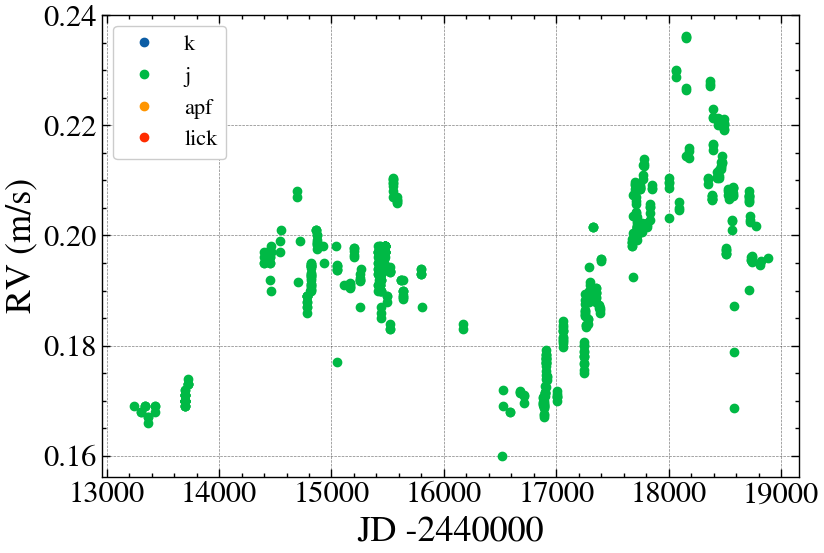

In [121]:
for i in telescopes:
    plt.errorbar(hd26965.jd[hd26965['tel']==i] -2440000, hd26965.sval[hd26965['tel']==i], fmt = 'o', label = i)
plt.xlabel('JD -2440000')
plt.ylabel('RV (m/s)')
plt.legend()

In [122]:
timeseries = np.array(hd26965.sval[hd26965['tel']=='j']).reshape(1,-1)
rvs = np.array(hd26965.mnvel[hd26965['tel']=='j'])
time =np.array(hd26965['jd'][hd26965['tel']=='j'])
fdac_26 = fdac.fdac(time,rvs, timeseries, ['RV', 'S-index'])

Mean Nyquist frequency:  0.052210325133932034 

Median Nyquist frequency:  800.0001668930402 

10% trimmed Mean Nyquist frequency:  0.1820113345770824 

20% trimmed mean Nyqusit frequenct:  0.3829250448599489


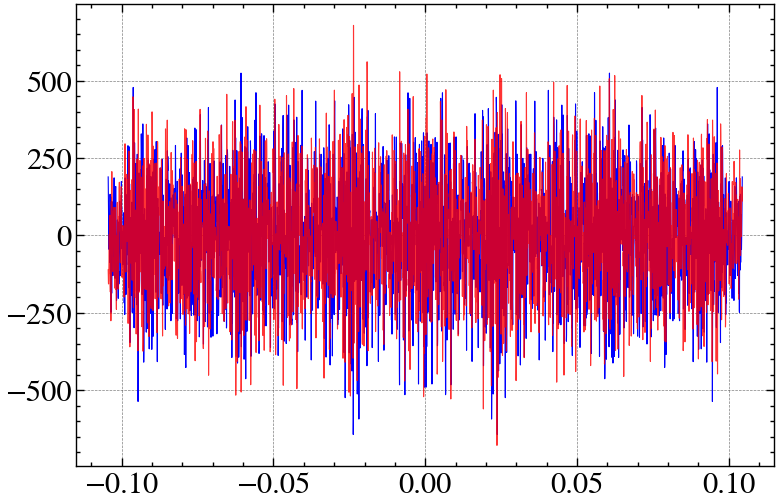

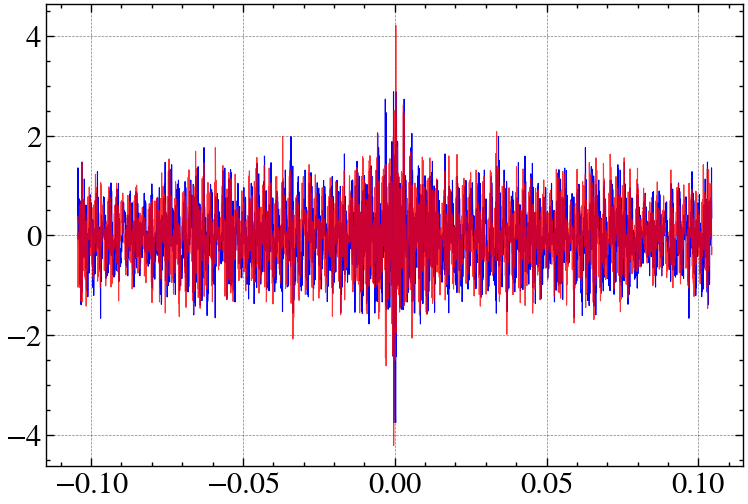

In [132]:
fdac_26.frequency_grid(2*fdac_26.Nyq_meandt, oversample=4)
fdac_26.computeNFFT()
plt.plot(fdac_26.fgrid, fdac_26.fft_list[0].real, label="Re", lw=0.8, color = 'b')
plt.plot(fdac_26.fgrid, fdac_26.fft_list[0].imag, label="Im", lw=0.8, alpha=0.8, color = 'r')
plt.figure()
plt.plot(fdac_26.fgrid, fdac_26.fft_list[1].real, label="Re", lw=0.8, color = 'b')
plt.plot(fdac_26.fgrid, fdac_26.fft_list[1].imag, label="Im", lw=0.8, alpha=0.8, color = 'r')

In [133]:
fdac_26.linear_reg()

Coefficients
----
Coefficients: 
 [[97.37289761 -9.92927028]
 [ 9.94462361 97.51678663]]

Intercept
---------
Intercept: 
 0.0


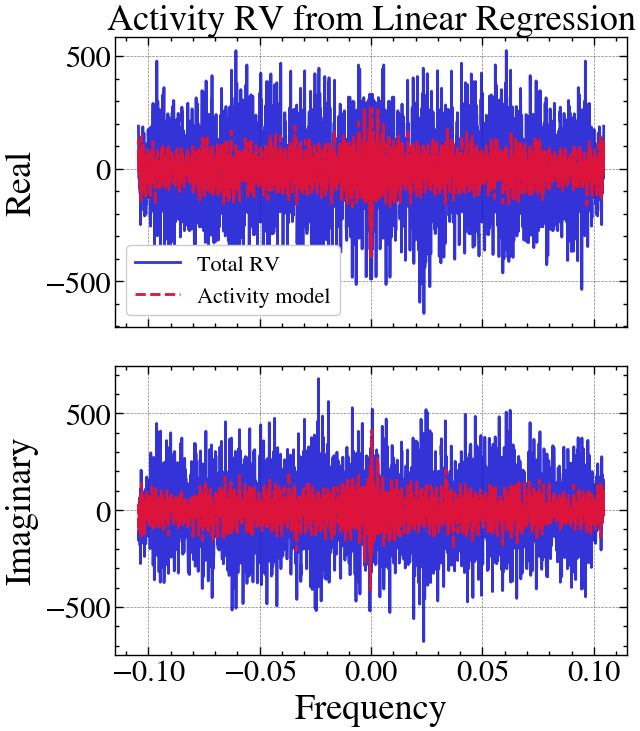

In [134]:
fdac_26.fftac_plot()

15.218602309725306 3.808318914382254e-07
Raw standard deviation 3.8490
Variance ratio: 0.1243
Should be 1: 1.0000000000000002
Should be equal: 1.3569 1.3569
Inversion fully computed
Std dev of clean RV: 11.01435406857914


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


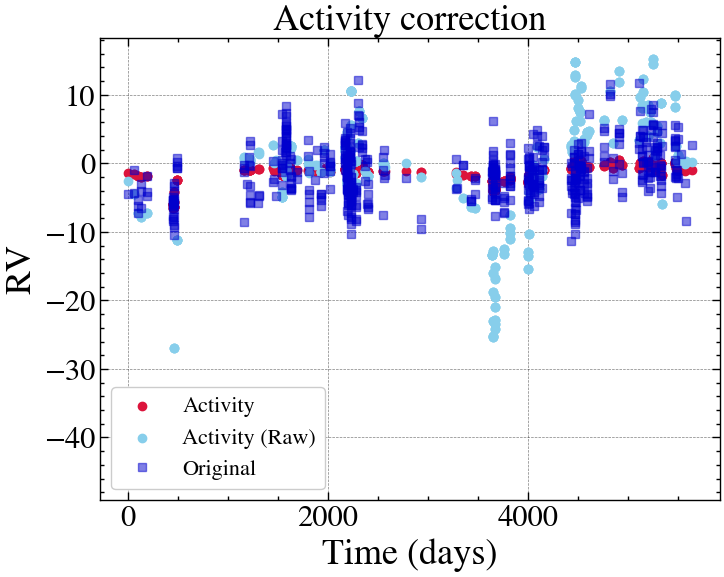

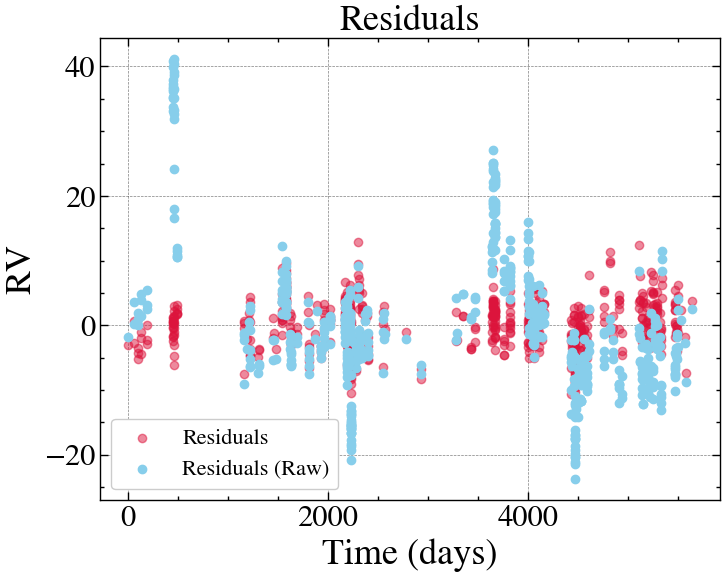

In [135]:
fdac_26.inverfft()
fdac_26.activityplot(clean = True)

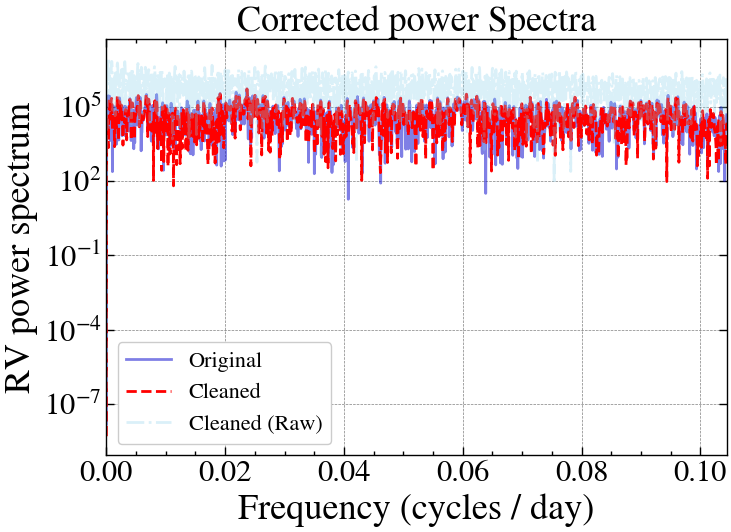

In [136]:
fdac_26.residual_powplot(log=True)
#plt.ylim(1e-2, 1e7)
#plt.xlim(-0.001,0.1)
#plt.axvline(1/17.05, color='k', ls='--')

(0.0, 0.1)

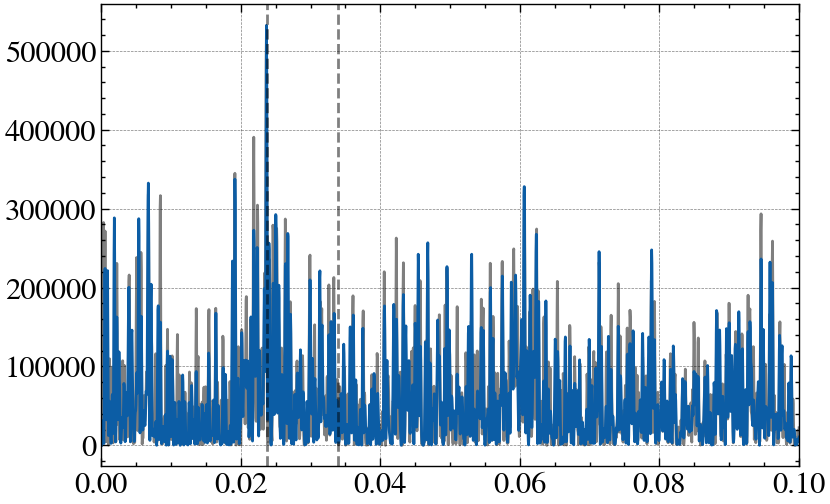

In [139]:
indeces = fdac_26.fgrid>=0
plt.plot(fdac_26.fgrid[indeces], np.abs(fdac_26.first_FFT[indeces])**2, color='k', alpha=0.5)
plt.plot(fdac_26.fgrid[indeces], np.abs(fdac_26.residuals_FFT[indeces])**2,alpha=1)
plt.axvline(1/42, color='k', ls='--', alpha=0.5)
plt.axvline(1/29.5, color='k', ls='--', alpha=0.5)
plt.xlim(0, 0.1)

## 5. HD 99491 but the data from LCES

In [142]:
#read the rv data
data = pd.read_csv('../../data/hd99491rv.tsv', delimiter= ';', comment = '#')
data = data.drop([0,1]).reset_index(drop=True)
for i in data.columns[1:]:
    data[i] = pd.to_numeric(data[i], errors='coerce')
data.head()

,Name,BJD,RVcor,e_RVcor,S,H,Count,ExpTime,CorV,e_CorV
0,HD99491,2.450419e+06,11.834,1.624,0.2403,NaN,287910,475,0.086,1.083
1,HD99491,2.450463e+06,0.452,1.324,0.2190,NaN,127138,100,0.268,0.601
2,HD99491,2.450546e+06,3.041,1.409,0.2125,NaN,207853,600,-2.061,0.543
3,HD99491,2.450786e+06,9.839,1.309,0.2321,NaN,74351,255,-1.209,0.390
4,HD99491,2.450840e+06,0.624,1.182,0.2184,NaN,172508,148,-0.494,0.272


Text(0.5, 0, 'BJD')

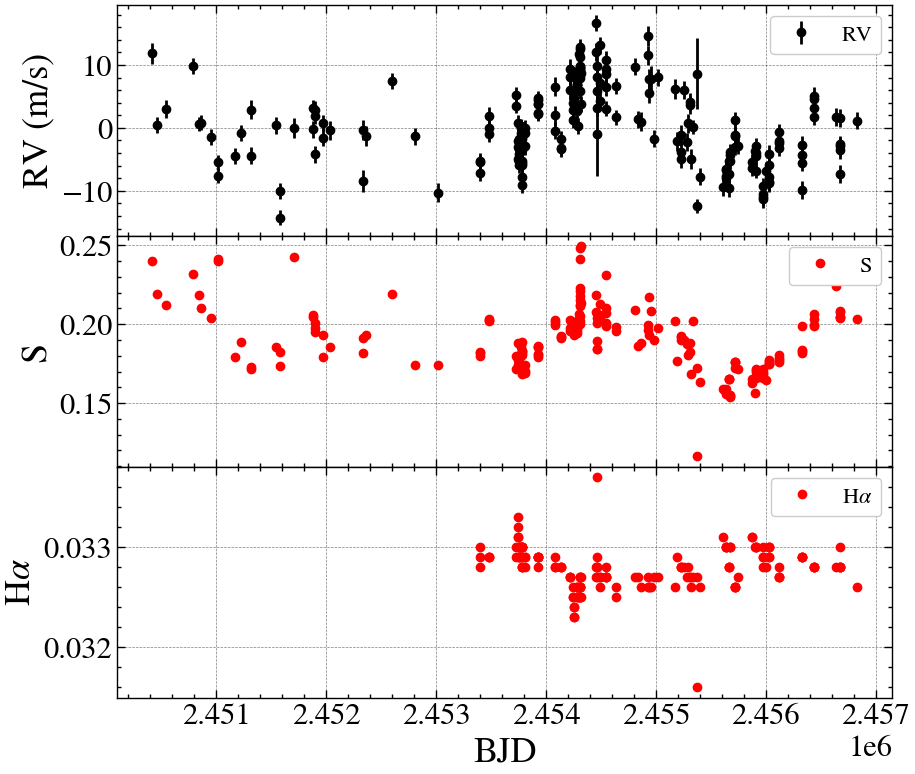

In [143]:
#plot the velocities, S index and H alpha
fig , ax = plt.subplots(figsize = (10,9), nrows = 3, sharex = True, \
                               gridspec_kw = {'wspace':0, 'hspace':0})
labels= ['RV','S', r'H$\alpha$']
for i in range(3):
    if i ==0:
        ax[i].errorbar(data['BJD'], data['RVcor'], yerr = data['e_RVcor'], \
                       fmt = 'o',color ='k', label = labels[i])
        ax[i].set_ylabel('RV (m/s)')
        ax[i].legend()
    else:
        ax[i].errorbar(data['BJD'], data[data.columns[i+3]], color ='r',fmt = 'o', label =labels[i])
        ax[i].set_ylabel(labels[i])
        ax[i].legend()
ax[2].set_xlabel('BJD')

In [144]:
timeseries = np.array(data['S']).reshape(1,-1)
rvs = np.array(data['RVcor'])
time =np.array(data['BJD'])
fdac_91 = fdac.fdac(time,rvs, timeseries, ['RV', 'S-index'])

Mean Nyquist frequency:  0.015445555722709076 

Median Nyquist frequency:  0.49732934136502227 

10% trimmed Mean Nyquist frequency:  0.021746745893055242 

20% trimmed mean Nyqusit frequenct:  0.032074046657287136


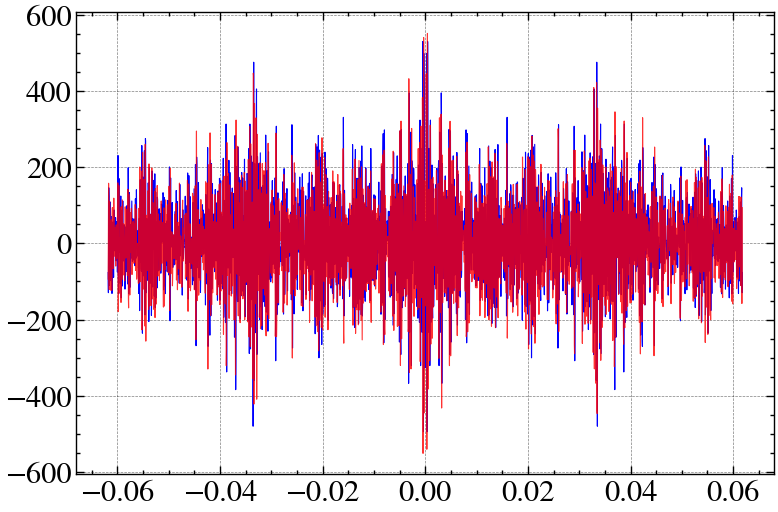

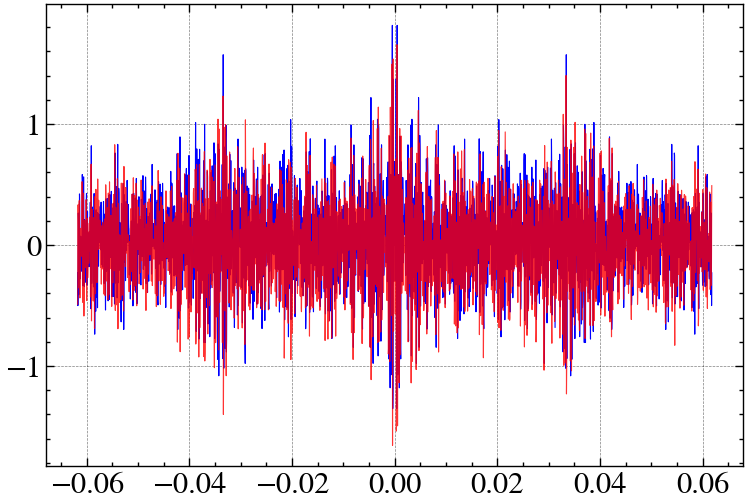

In [145]:
fdac_91.frequency_grid(4*fdac_91.Nyq_meandt, oversample=4)
fdac_91.computeNFFT()
plt.plot(fdac_91.fgrid, fdac_91.fft_list[0].real, label="Re", lw=0.8, color = 'b')
plt.plot(fdac_91.fgrid, fdac_91.fft_list[0].imag, label="Im", lw=0.8, alpha=0.8, color = 'r')
plt.figure()
plt.plot(fdac_91.fgrid, fdac_91.fft_list[1].real, label="Re", lw=0.8, color = 'b')
plt.plot(fdac_91.fgrid, fdac_91.fft_list[1].imag, label="Im", lw=0.8, alpha=0.8, color = 'r')

In [146]:
fdac_91.linear_reg()

Coefficients
----
Coefficients: 
 [[248.66431462 -20.24411601]
 [ 20.81632856 249.02697321]]

Intercept
---------
Intercept: 
 0.0


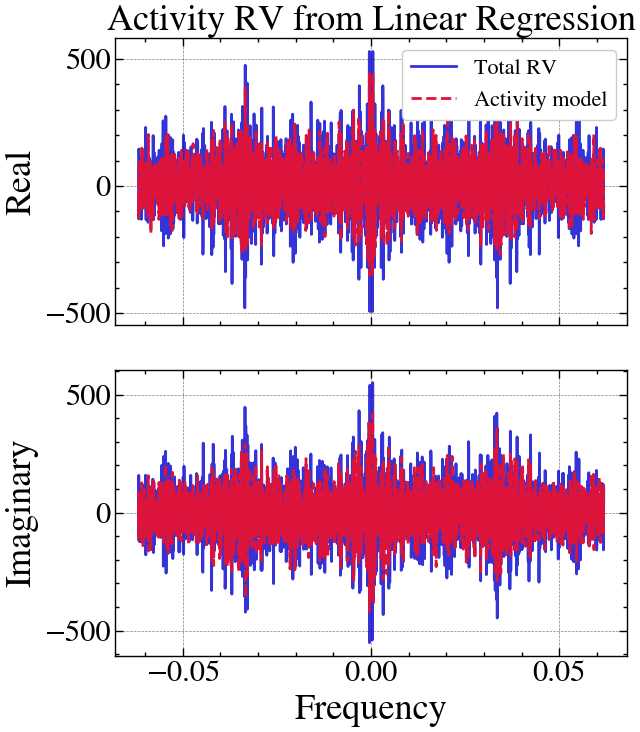

In [147]:
fdac_91.fftac_plot()

78.7830231222785 1.2705599675360383e-06
Raw standard deviation 6.2481
Variance ratio: 0.5973
Should be 1: 0.9999999999999999
Should be equal: 4.8290 4.8290
Inversion fully computed
Std dev of clean RV: 19.23078916064204


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


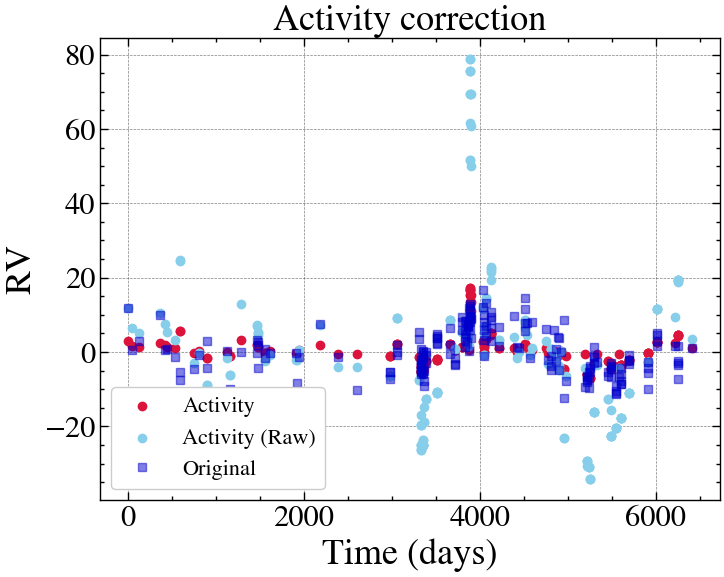

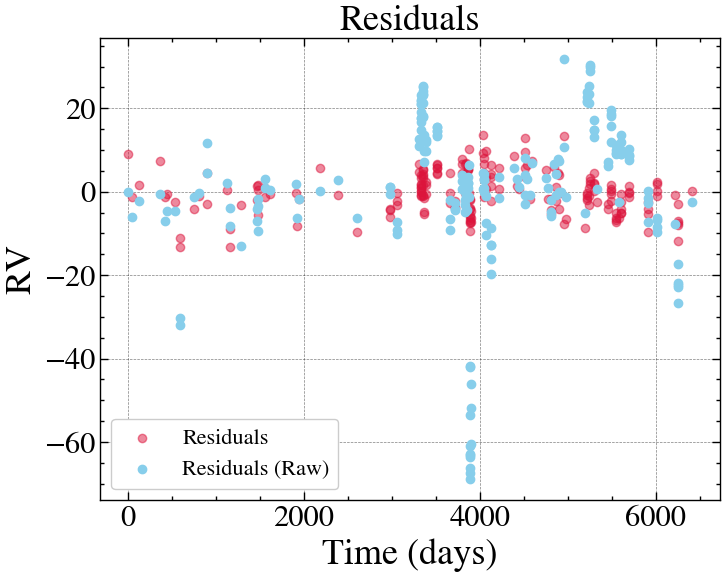

In [148]:
fdac_91.inverfft()
fdac_91.activityplot(clean = True)

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


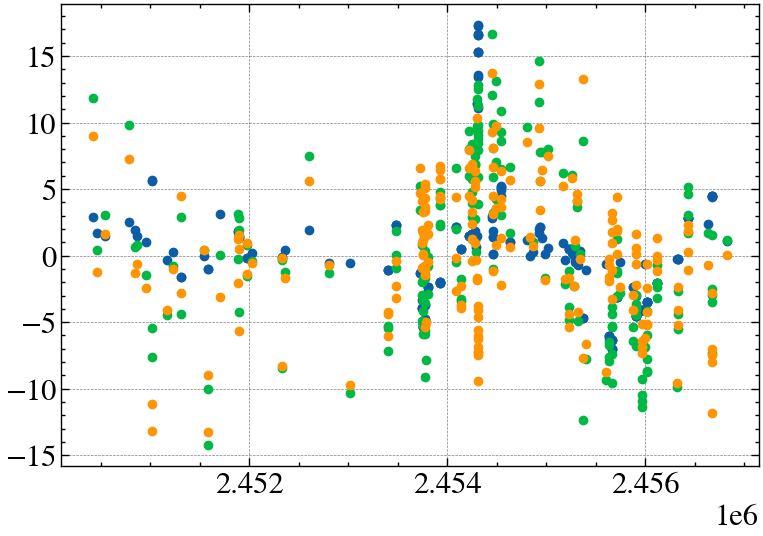

In [160]:
plt.plot(time, fdac_91.activity, 'o')
plt.plot(time, rvs, 'o')
plt.plot(time, fdac_91.residuals, 'o')

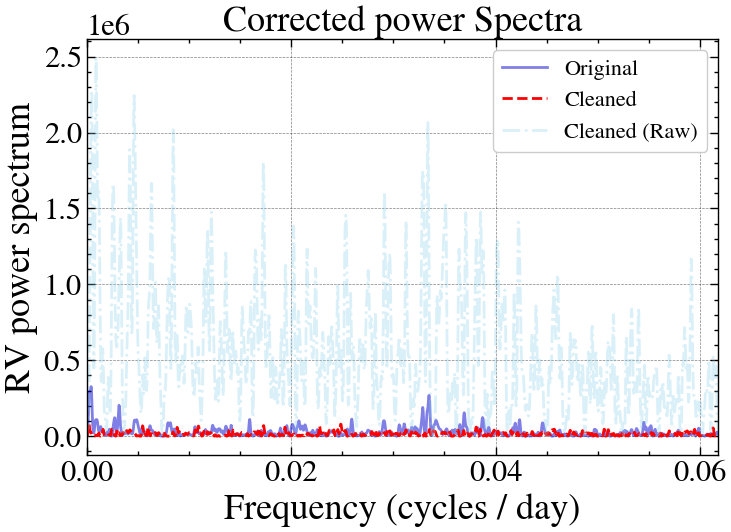

In [158]:
fdac_91.residual_powplot()

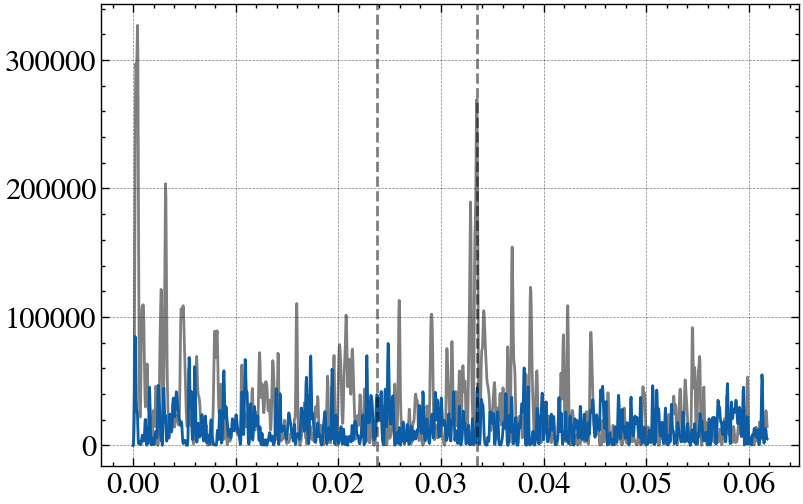

In [164]:
indeces = fdac_91.fgrid>=0
plt.plot(fdac_91.fgrid[indeces], np.abs(fdac_91.first_FFT[indeces])**2, color='k', alpha=0.5)
plt.plot(fdac_91.fgrid[indeces], np.abs(fdac_91.residuals_FFT[indeces])**2,alpha=1)
plt.axvline(1/42, color='k', ls='--', alpha=0.5)
plt.axvline(1/29.8, color='k', ls='--', alpha=0.5)